# Stockholm Statistikområden (RegSO) - Analys & Visualisering

Data från SCB med matplotlib-grafer och DuckDB SQL-analyser

**OBS:** RegSO (Regionala statistikområden) är SCB:s geografiska indelning för statistik.  
Detta är INTE samma som Stockholms stads administrativa stadsdelsnämnder.

- **127 RegSO-områden** i Stockholms kommun
- **14 stadsdelsnämnder** (administrativa enheter)
- RegSO är finare uppdelning och liknar "stadsdelar i folkmun"

In [1]:
import requests
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import matplotlib as mpl
import duckdb
import numpy as np
from pathlib import Path

# Matplotlib inställningar
plt.style.use('seaborn-v0_8-darkgrid')
mpl.rcParams['figure.figsize'] = (12, 6)
mpl.rcParams['font.size'] = 10

# ── Sökvägar ────────────────────────────────────────────────────────────────
# Notebooken ligger i EDA/ – data_files och outputs är syskon-mappar
BASE_DIR   = Path.cwd()                    # EDA/
DATA_DIR   = BASE_DIR.parent / "data_files"  # data_files/
OUTPUT_DIR = BASE_DIR / "outputs"          # EDA/outputs/
OUTPUT_DIR.mkdir(exist_ok=True)

# ── SCB API ──────────────────────────────────────────────────────────────────
BASE_URL = "https://statistikdatabasen.scb.se/api/v2"
LANG     = "sv"

TABLE_FOLKM_DESO = "TAB6574"
TABLE_HUSHALL    = "TAB6568"
TABLE_BOENDE     = "TAB6638"

BATCH_SIZE = 10

print("✓ Bibliotek importerade")
print(f"  DATA_DIR   : {DATA_DIR}")
print(f"  OUTPUT_DIR : {OUTPUT_DIR}")

✓ Bibliotek importerade
  DATA_DIR   : c:\Users\chris\Documents\github\UrbanPulse\data_files
  OUTPUT_DIR : c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs


In [2]:
# Hjälpfunktioner

def get_metadata(table_id):
    url = f"{BASE_URL}/tables/{table_id}/metadata?lang={LANG}"
    r = requests.get(url)
    r.raise_for_status()
    return r.json()

def stockholm_regso_koder(meta):
    """Hämta RegSO-koder för Stockholm med områdesnamn"""
    region_cats   = meta["dimension"]["Region"]["category"]["index"]
    region_labels = meta["dimension"]["Region"]["category"]["label"]
    regso = {k: region_labels[k] for k in region_cats.keys()
             if k.startswith("0180") and k.endswith("_RegSO2025")}
    print(f"  {len(regso)} RegSO-områden hittade")
    return regso

def jsonstat2_to_df(data, region_namn_map):
    """Konvertera JSON-stat2 till DataFrame och lägg till statistikområdesnamn"""
    dims   = data["id"]
    values = data["value"]
    dim_vals = []
    for d in dims:
        if d == "Region":
            dim_vals.append(list(data["dimension"][d]["category"]["index"].keys()))
        else:
            dim_vals.append(list(data["dimension"][d]["category"]["label"].values()))

    df = pd.DataFrame(list(itertools.product(*dim_vals)), columns=dims)
    df["value"] = values

    # Lägg till statistikområdesnamn (ta bort "Stockholm (" prefix)
    df["Statistikområde"] = df["Region"].map(
        lambda x: region_namn_map.get(x, x).replace("Stockholm (", "").replace(")", "")
    )

    # Flytta Statistikområde till andra kolumnen
    cols = df.columns.tolist()
    cols.insert(1, cols.pop(cols.index("Statistikområde")))
    return df[cols]

def fetch_batch(table_id, regso_map, extra_filters):
    """Hämta data i batcher om 10 regioner"""
    koder   = list(regso_map.keys())
    batches = [koder[i:i + BATCH_SIZE] for i in range(0, len(koder), BATCH_SIZE)]
    print(f"Hämtar {len(koder)} områden i {len(batches)} batcher...")

    dfs = []
    for i, batch in enumerate(batches, 1):
        params = [
            f"lang={LANG}",
            "outputFormat=JSON-stat2",
            f"valueCodes[Region]={','.join(batch)}",
        ]
        for dim, vals in extra_filters.items():
            encoded_vals = [v.replace("+", "%2B") for v in vals]
            params.append(f"valueCodes[{dim}]={','.join(encoded_vals)}")

        url = f"{BASE_URL}/tables/{table_id}/data?" + "&".join(params)

        try:
            r = requests.get(url, timeout=15)
            if r.status_code == 200:
                df = jsonstat2_to_df(r.json(), regso_map)
                dfs.append(df)
        except Exception as e:
            print(f"  ⚠️  Batch {i} misslyckades: {e}")

        if i % 5 == 0:
            print(f"  ✓ {i}/{len(batches)} batcher klara")

    if not dfs:
        return None

    result = pd.concat(dfs, ignore_index=True)
    print(f"✅ Klart – {len(result)} rader")
    return result

print("✓ Funktioner laddade")

✓ Funktioner laddade


---
## Hämta data från SCB

In [3]:
# 1. Folkmängd
print("\n" + "="*60)
print("FOLKMÄNGD")
print("="*60)
meta_folkm  = get_metadata(TABLE_FOLKM_DESO)
regso_folkm = stockholm_regso_koder(meta_folkm)
df_folkm = fetch_batch(TABLE_FOLKM_DESO, regso_folkm, {
    "Alder":        ["totalt"],
    "Kon":          ["1+2"],
    "ContentsCode": ["000007Y7"],
    "Tid":          ["2024"],
})


FOLKMÄNGD
  127 RegSO-områden hittade
Hämtar 127 områden i 13 batcher...
  ✓ 5/13 batcher klara
  ✓ 10/13 batcher klara
✅ Klart – 127 rader


In [4]:
# 2. Hushåll
print("\n" + "="*60)
print("HUSHÅLL")
print("="*60)
meta_hushall  = get_metadata(TABLE_HUSHALL)
regso_hushall = stockholm_regso_koder(meta_hushall)
df_hushall = fetch_batch(TABLE_HUSHALL, regso_hushall, {
    "Hushallstyp":  ["TOTALT"],
    "ContentsCode": ["000007Y1"],
    "Tid":          ["2024"],
})


HUSHÅLL
  127 RegSO-områden hittade
Hämtar 127 områden i 13 batcher...
  ✓ 5/13 batcher klara
  ✓ 10/13 batcher klara
✅ Klart – 127 rader


In [5]:
# 3. Boende
print("\n" + "="*60)
print("BOENDE")
print("="*60)
meta_boende  = get_metadata(TABLE_BOENDE)
regso_boende = stockholm_regso_koder(meta_boende)
df_boende = fetch_batch(TABLE_BOENDE, regso_boende, {
    "Upplatelseform": ["1", "2", "3", "ÖVRIGT"],
    "ContentsCode":   ["00000864"],
    "Tid":            ["2024"],
})


BOENDE
  127 RegSO-områden hittade
Hämtar 127 områden i 13 batcher...
  ✓ 5/13 batcher klara
  ✓ 10/13 batcher klara
✅ Klart – 508 rader


---
## DuckDB SQL-Analyser

In [6]:
# Skapa DuckDB-anslutning och registrera DataFrames
con = duckdb.connect()
con.register('folkm',   df_folkm)
con.register('hushall', df_hushall)
con.register('boende',  df_boende)

print("✅ Data registrerad i DuckDB")
print("\nTillgängliga tabeller:")
print("  - folkm (befolkning)")
print("  - hushall")
print("  - boende")

✅ Data registrerad i DuckDB

Tillgängliga tabeller:
  - folkm (befolkning)
  - hushall
  - boende


### SQL Query 1: Topp 10 största områdena

In [7]:
query1 = """
SELECT 
    Statistikområde,
    value AS Befolkning
FROM folkm
ORDER BY value DESC
LIMIT 10
"""

top10_befolkning = con.execute(query1).df()
print("\n📊 Topp 10 största statistikområdena:\n")
display(top10_befolkning)


📊 Topp 10 största statistikområdena:



,Statistikområde,Befolkning
0,Gärdet,23101
1,Östra Katarina,20678
2,Årsta,20638
3,Västra Matteus,20629
4,Södra Hammarbyhamnen,20300
5,Kungsholm,19790
6,Hässelby Villastad,18974
7,Tensta,18545
8,Liljeholmen,17930
9,Rinkeby,17096


### SQL Query 2: JOIN - Befolkning + Hushåll + Personer per hushåll

In [8]:
query2 = """
SELECT 
    f.Statistikområde,
    f.value                              AS Befolkning,
    h.value                              AS Hushall,
    ROUND(f.value::FLOAT / h.value, 2)   AS PersonerPerHushall
FROM folkm f
JOIN hushall h ON f.Region = h.Region
ORDER BY PersonerPerHushall DESC
LIMIT 15
"""

df_combined = con.execute(query2).df()
print("\n🏠 Områden med flest personer per hushåll:\n")
display(df_combined)


🏠 Områden med flest personer per hushåll:



,Statistikområde,Befolkning,Hushall,PersonerPerHushall
0,Herrängen,3878,1233,3.15
1,Långsjö,3032,972,3.12
2,Kälvesta,4566,1466,3.11
3,Bromma kyrka,2694,869,3.10
4,Södra Ängby,1623,540,3.01
5,Mälarhöjden,4404,1478,2.98
6,Rinkeby,17096,5731,2.98
7,Nälsta,5040,1697,2.97
8,Ålsten,3205,1080,2.97
9,Eneby,869,300,2.90


### SQL Query 3: Boendeform-fördelning per område

In [9]:
query3 = """
SELECT 
    Statistikområde,
    SUM(CASE WHEN Upplatelseform = 'hyresrätt'   THEN value ELSE 0 END) AS Hyresratt,
    SUM(CASE WHEN Upplatelseform = 'bostadsrätt' THEN value ELSE 0 END) AS Bostadsratt,
    SUM(CASE WHEN Upplatelseform = 'äganderätt'  THEN value ELSE 0 END) AS Aganderatt,
    SUM(value)                                                           AS TotalBostader
FROM boende
GROUP BY Statistikområde
HAVING TotalBostader > 0
ORDER BY TotalBostader DESC
LIMIT 10
"""

df_boendeform = con.execute(query3).df()
print("\n🔑 Topp 10 områden - Boendeform:\n")
display(df_boendeform)


🔑 Topp 10 områden - Boendeform:



,Statistikområde,Hyresratt,Bostadsratt,Aganderatt,TotalBostader
0,Gärdet,6240.0,9322.0,10.0,15572.0
1,Kungsholm,3067.0,9572.0,0.0,12639.0
2,Östra Katarina,6071.0,6511.0,5.0,12587.0
3,Västra Matteus,3492.0,8976.0,97.0,12565.0
4,Årsta,3488.0,7954.0,0.0,11442.0
5,Östra Sankt Göran,3075.0,7601.0,0.0,10676.0
6,Oscars kyrka,2291.0,7718.0,7.0,10016.0
7,Norra Högalid,4093.0,5504.0,1.0,9598.0
8,Södra Hammarbyhamnen,3395.0,6124.0,0.0,9519.0
9,Västra Katarina,4914.0,4210.0,0.0,9124.0


### SQL Query 4: Äganderätt (villor) - vilka områden har flest?

In [10]:
query4 = """
SELECT 
    Statistikområde,
    SUM(CASE WHEN Upplatelseform = 'äganderätt' THEN value ELSE 0 END)       AS Aganderatt,
    SUM(value)                                                                AS TotalBostader,
    ROUND(
        100.0 * SUM(CASE WHEN Upplatelseform = 'äganderätt' THEN value ELSE 0 END)
        / SUM(value), 1
    )                                                                         AS AganderattProcent
FROM boende
GROUP BY Statistikområde
HAVING TotalBostader > 100   -- Filtrera bort mycket små områden
ORDER BY AganderattProcent DESC
LIMIT 20
"""

df_aganderatt = con.execute(query4).df()
print("\n🏡 Områden med högst andel äganderätt (villor/radhus):\n")
display(df_aganderatt)


🏡 Områden med högst andel äganderätt (villor/radhus):



,Statistikområde,Aganderatt,TotalBostader,AganderattProcent
0,Kälvesta,1451.0,1459.0,99.5
1,Herrängen,1119.0,1181.0,94.8
2,Eneby,273.0,295.0,92.5
3,Södra Ängby,495.0,549.0,90.2
4,Långsjö,835.0,941.0,88.7
5,Bällsta,240.0,271.0,88.6
6,Bromma kyrka,744.0,864.0,86.1
7,Flysta,656.0,832.0,78.8
8,Höglandet,366.0,478.0,76.6
9,Nälsta,1295.0,1698.0,76.3


---
## Matplotlib Visualiseringar

### Graf 1: Topp 15 största områdena (befolkning)

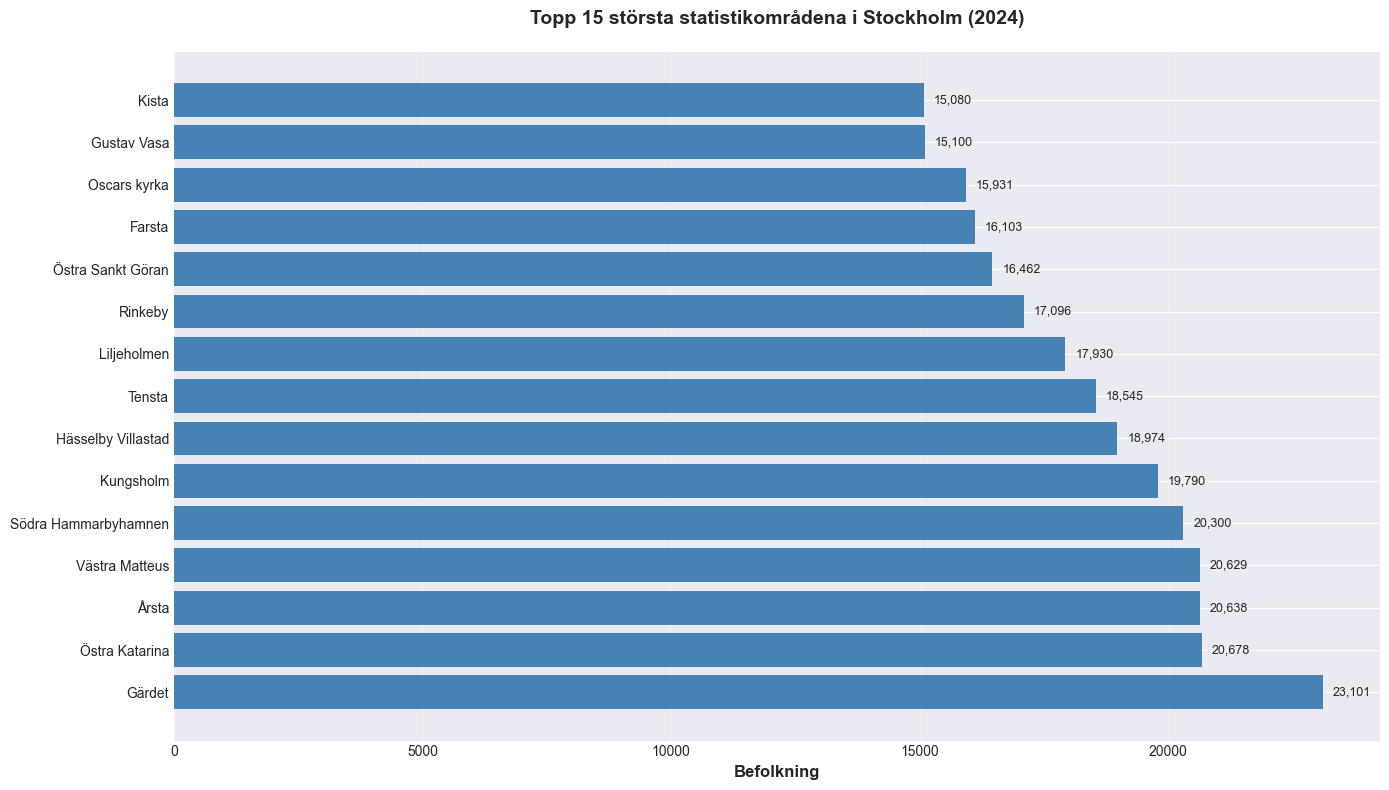

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\top15_befolkning.png


In [11]:
top15 = con.execute("""
    SELECT Statistikområde, value AS Befolkning
    FROM folkm
    ORDER BY value DESC
    LIMIT 15
""").df()

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(top15)), top15['Befolkning'], color='steelblue')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['Statistikområde'])
ax.set_xlabel('Befolkning', fontsize=12, fontweight='bold')
ax.set_title('Topp 15 största statistikområdena i Stockholm (2024)',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 200, bar.get_y() + bar.get_height() / 2,
            f'{int(width):,}', ha='left', va='center', fontsize=9)

plt.tight_layout()
out = OUTPUT_DIR / 'top15_befolkning.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {out}")

### Graf 2: Personer per hushåll - Topp & Botten

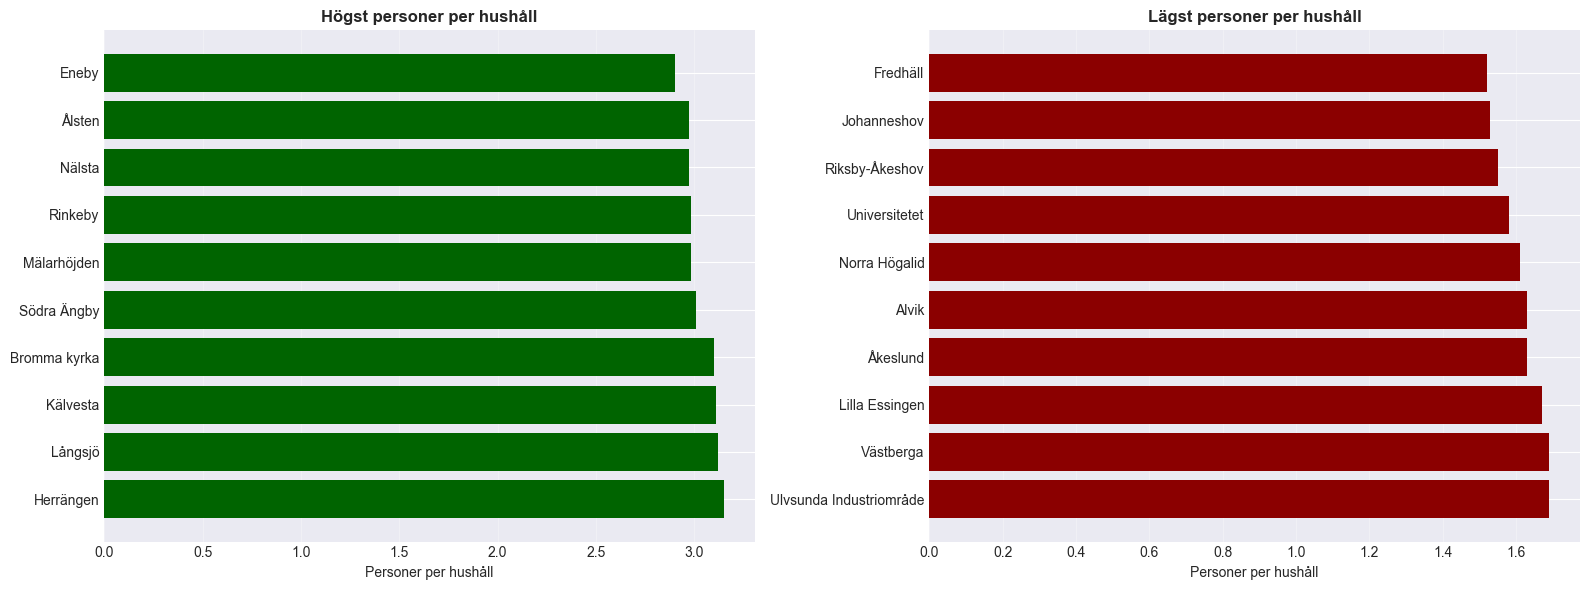

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\personer_per_hushall.png


In [12]:
pers_per_hus = con.execute("""
    SELECT 
        f.Statistikområde,
        ROUND(f.value::FLOAT / h.value, 2) AS PersonerPerHushall
    FROM folkm f
    JOIN hushall h ON f.Region = h.Region
    ORDER BY PersonerPerHushall DESC
""").df()

top10    = pers_per_hus.head(10)
bottom10 = pers_per_hus.tail(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.barh(range(len(top10)), top10['PersonerPerHushall'], color='darkgreen')
ax1.set_yticks(range(len(top10)))
ax1.set_yticklabels(top10['Statistikområde'])
ax1.set_xlabel('Personer per hushåll')
ax1.set_title('Högst personer per hushåll', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

ax2.barh(range(len(bottom10)), bottom10['PersonerPerHushall'], color='darkred')
ax2.set_yticks(range(len(bottom10)))
ax2.set_yticklabels(bottom10['Statistikområde'])
ax2.set_xlabel('Personer per hushåll')
ax2.set_title('Lägst personer per hushåll', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
out = OUTPUT_DIR / 'personer_per_hushall.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {out}")

### Graf 3: Boendeform - Cirkeldiagram (hela Stockholm)

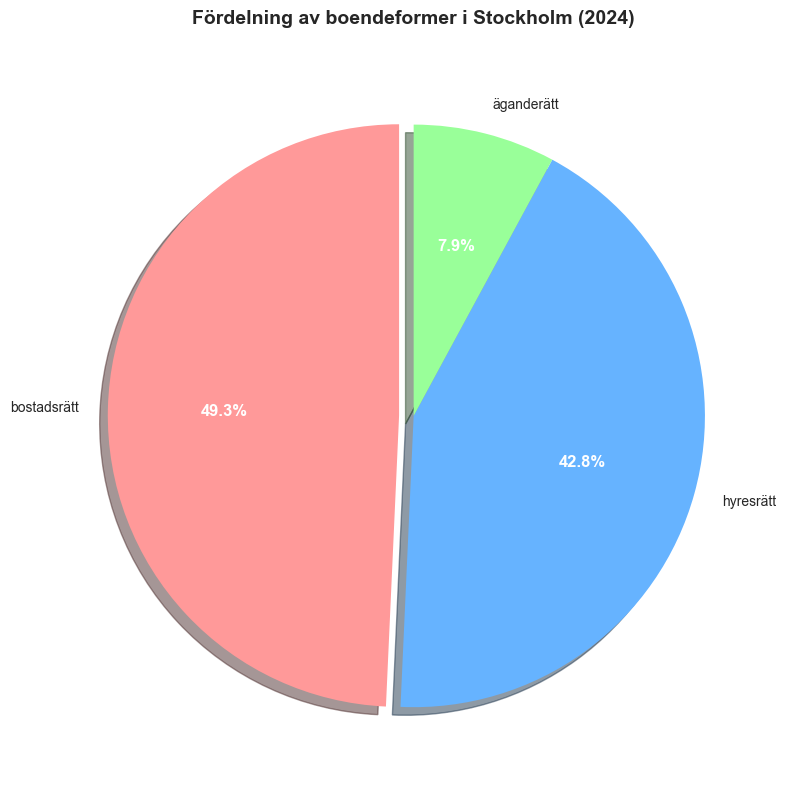

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\boendeform_cirkel.png


In [13]:
boendeform_total = con.execute("""
    SELECT 
        Upplatelseform,
        SUM(value) AS Antal
    FROM boende
    WHERE Upplatelseform != 'uppgift saknas'
    GROUP BY Upplatelseform
    ORDER BY Antal DESC
""").df()

fig, ax = plt.subplots(figsize=(10, 8))
colors  = ['#ff9999', '#66b3ff', '#99ff99']
explode = (0.05, 0, 0)

wedges, texts, autotexts = ax.pie(
    boendeform_total['Antal'],
    labels=boendeform_total['Upplatelseform'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=explode,
    shadow=True
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

ax.set_title('Fördelning av boendeformer i Stockholm (2024)',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
out = OUTPUT_DIR / 'boendeform_cirkel.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {out}")

### Graf 4: Stacked Bar - Boendeform för utvalda områden

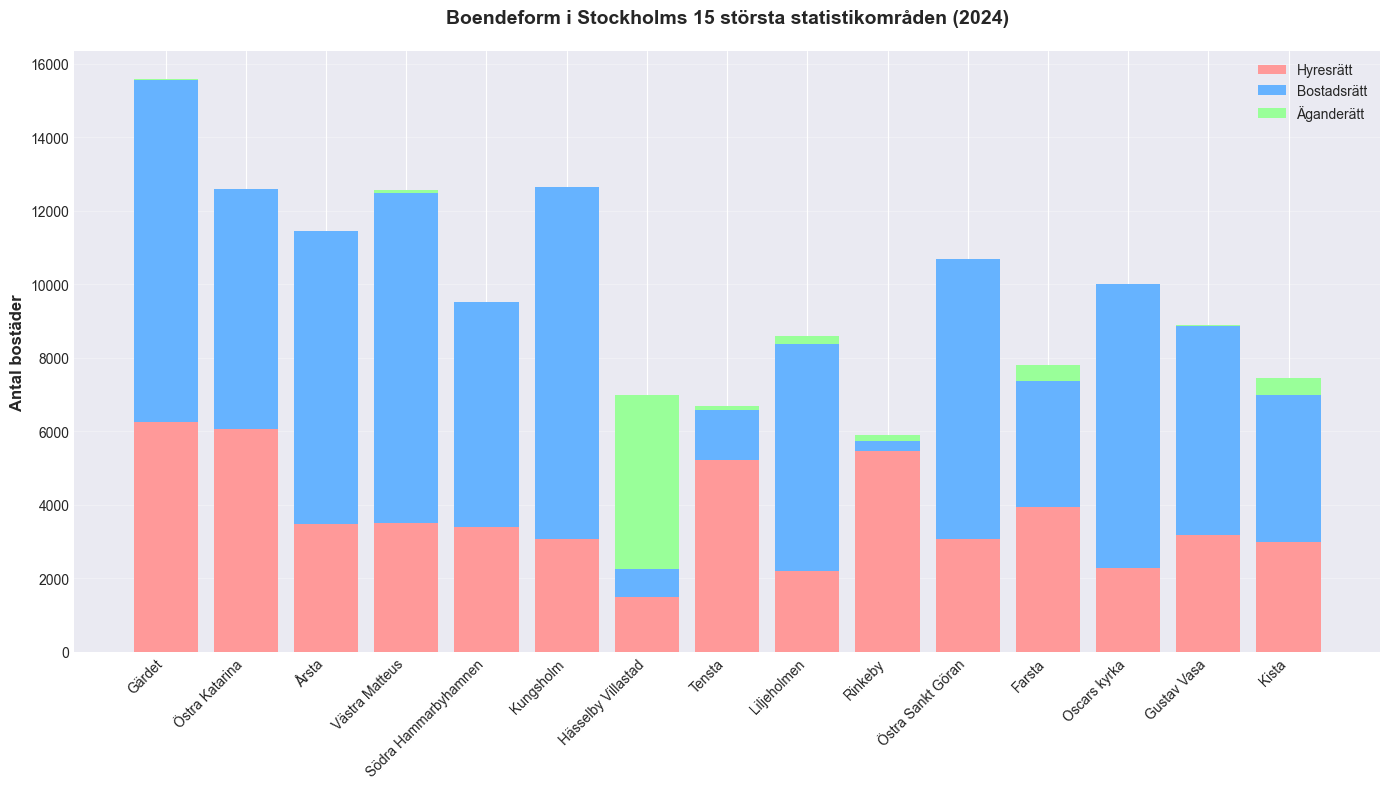

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\boendeform_stacked.png


In [14]:
top_omraden = con.execute("""
    SELECT Statistikområde
    FROM folkm
    ORDER BY value DESC
    LIMIT 15
""").df()['Statistikområde'].tolist()

placeholders   = ','.join(["'" + s + "'" for s in top_omraden])
boendeform_data = con.execute(f"""
    SELECT 
        Statistikområde,
        SUM(CASE WHEN Upplatelseform = 'hyresrätt'   THEN value ELSE 0 END) AS Hyresratt,
        SUM(CASE WHEN Upplatelseform = 'bostadsrätt' THEN value ELSE 0 END) AS Bostadsratt,
        SUM(CASE WHEN Upplatelseform = 'äganderätt'  THEN value ELSE 0 END) AS Aganderatt
    FROM boende
    WHERE Statistikområde IN ({placeholders})
    GROUP BY Statistikområde
""").df()

boendeform_data['sort_order'] = boendeform_data['Statistikområde'].apply(
    lambda x: top_omraden.index(x) if x in top_omraden else 999
)
boendeform_data = boendeform_data.sort_values('sort_order')

fig, ax = plt.subplots(figsize=(14, 8))
x = range(len(boendeform_data))
w = 0.8

ax.bar(x, boendeform_data['Hyresratt'],   w, label='Hyresrätt',   color='#ff9999')
ax.bar(x, boendeform_data['Bostadsratt'], w, label='Bostadsrätt', color='#66b3ff',
       bottom=boendeform_data['Hyresratt'])
ax.bar(x, boendeform_data['Aganderatt'],  w, label='Äganderätt',  color='#99ff99',
       bottom=boendeform_data['Hyresratt'] + boendeform_data['Bostadsratt'])

ax.set_ylabel('Antal bostäder', fontsize=12, fontweight='bold')
ax.set_title('Boendeform i Stockholms 15 största statistikområden (2024)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(boendeform_data['Statistikområde'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
out = OUTPUT_DIR / 'boendeform_stacked.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {out}")

### Graf 5: Scatter plot - Befolkning vs Hushåll

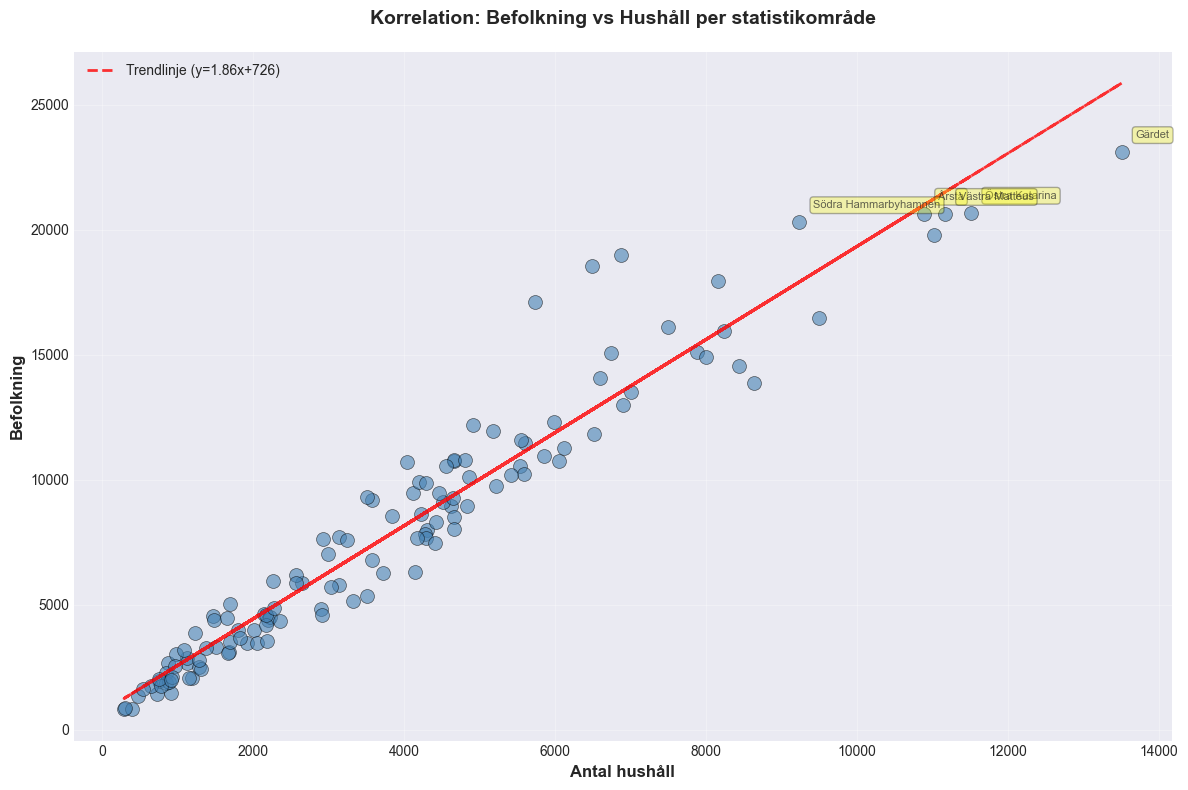

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\scatter_befolkning_hushall.png


In [15]:
scatter_data = con.execute("""
    SELECT 
        f.Statistikområde,
        f.value AS Befolkning,
        h.value AS Hushall
    FROM folkm f
    JOIN hushall h ON f.Region = h.Region
""").df()

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(scatter_data['Hushall'], scatter_data['Befolkning'],
           alpha=0.6, s=100, color='steelblue', edgecolors='black', linewidth=0.5)

z = np.polyfit(scatter_data['Hushall'], scatter_data['Befolkning'], 1)
p = np.poly1d(z)
ax.plot(scatter_data['Hushall'], p(scatter_data['Hushall']),
        'r--', alpha=0.8, linewidth=2, label=f'Trendlinje (y={z[0]:.2f}x+{z[1]:.0f})')

for idx, row in scatter_data.nlargest(5, 'Befolkning').iterrows():
    ax.annotate(row['Statistikområde'],
                xy=(row['Hushall'], row['Befolkning']),
                xytext=(10, 10), textcoords='offset points',
                fontsize=8, alpha=0.7,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

ax.set_xlabel('Antal hushåll', fontsize=12, fontweight='bold')
ax.set_ylabel('Befolkning', fontsize=12, fontweight='bold')
ax.set_title('Korrelation: Befolkning vs Hushåll per statistikområde',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
out = OUTPUT_DIR / 'scatter_befolkning_hushall.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {out}")

---
## Exportera data till data_files/

In [16]:
# Spara rådata till data_files/ – matchar namngivningen av övriga filer i repot
if df_folkm is not None:
    path = DATA_DIR / 'stockholm_folkm_regso_2024.csv'
    df_folkm.to_csv(path, index=False)
    print(f"✓ {path}")

if df_hushall is not None:
    path = DATA_DIR / 'stockholm_hushall_regso_2024.csv'
    df_hushall.to_csv(path, index=False)
    print(f"✓ {path}")

if df_boende is not None:
    path = DATA_DIR / 'stockholm_boende_regso_2024.csv'
    df_boende.to_csv(path, index=False)
    print(f"✓ {path}")

# Spara kombinerad analysdata till EDA/outputs/
path = OUTPUT_DIR / 'stockholm_regso_analys.csv'
df_combined.to_csv(path, index=False)
print(f"✓ {path}")

print("\n✅ All data exporterad!")

✓ c:\Users\chris\Documents\github\UrbanPulse\data_files\stockholm_folkm_regso_2024.csv
✓ c:\Users\chris\Documents\github\UrbanPulse\data_files\stockholm_hushall_regso_2024.csv
✓ c:\Users\chris\Documents\github\UrbanPulse\data_files\stockholm_boende_regso_2024.csv
✓ c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\stockholm_regso_analys.csv

✅ All data exporterad!


---
## Sammanfattning

In [17]:
print("\n" + "="*60)
print("SAMMANFATTNING")
print("="*60)
print(f"\n📊 Data för {df_folkm['Statistikområde'].nunique()} RegSO-områden i Stockholm")
print(f"   Total befolkning : {df_folkm['value'].sum():,}")
print(f"   Totalt hushåll   : {df_hushall['value'].sum():,}")
print(f"   Totalt bostäder  : {df_boende['value'].sum():,}")
print(f"\n📈 Genererade grafer (EDA/outputs/):")
print("   1. top15_befolkning.png")
print("   2. personer_per_hushall.png")
print("   3. boendeform_cirkel.png")
print("   4. boendeform_stacked.png")
print("   5. scatter_befolkning_hushall.png")
print(f"\n💾 CSV-filer exporterade till data_files/:")
print("   - stockholm_folkm_regso_2024.csv")
print("   - stockholm_hushall_regso_2024.csv")
print("   - stockholm_boende_regso_2024.csv")
print("   + EDA/outputs/stockholm_regso_analys.csv")
print("\n✅ KLART!")
print("\n📝 OBS: RegSO-områden är SCB:s statistikindelning.")
print("   Detta är inte samma som Stockholms 14 administrativa stadsdelsnämnder.")


SAMMANFATTNING

📊 Data för 127 RegSO-områden i Stockholm
   Total befolkning : 995,574
   Totalt hushåll   : 485,661
   Totalt bostäder  : 522,654

📈 Genererade grafer (EDA/outputs/):
   1. top15_befolkning.png
   2. personer_per_hushall.png
   3. boendeform_cirkel.png
   4. boendeform_stacked.png
   5. scatter_befolkning_hushall.png

💾 CSV-filer exporterade till data_files/:
   - stockholm_folkm_regso_2024.csv
   - stockholm_hushall_regso_2024.csv
   - stockholm_boende_regso_2024.csv
   + EDA/outputs/stockholm_regso_analys.csv

✅ KLART!

📝 OBS: RegSO-områden är SCB:s statistikindelning.
   Detta är inte samma som Stockholms 14 administrativa stadsdelsnämnder.
